<a href="https://colab.research.google.com/github/anascherif/yoloshelf/blob/main/best%C3%A92point0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install -q ultralytics

### 1. Batch Crop Extraction
This snippet unzips your images and extracts all possible products from every shelf image found in the folder.

In [4]:
import os, shutil, torch, cv2, glob, numpy as np
from tqdm import tqdm

# Configuration
SHELF_ZIP = '/content/shelf_images.zip'
SHELF_EXTRACT_DIR = '/content/shelf_images_folder'
CROPS_DIR = '/content/crops'
DETECTION_VIS_DIR = '/content/detection_results'
YOLO_WEIGHTS ='/content/drive/MyDrive/best.pt'

# Prepare Folders
for d in [SHELF_EXTRACT_DIR, CROPS_DIR, DETECTION_VIS_DIR]:
    if os.path.exists(d): shutil.rmtree(d)
    os.makedirs(d)

if os.path.exists(SHELF_ZIP):
    !unzip -q {SHELF_ZIP} -d {SHELF_EXTRACT_DIR}
else:
    print(f"❌ Erreur: {SHELF_ZIP} introuvable.")

# Load Model
model = torch.hub.load('ultralytics/yolov5', 'custom', path=YOLO_WEIGHTS, force_reload=False)
model.conf = 0.35

# Search for images in ALL subdirectories
image_files = []
for root, dirs, files in os.walk(SHELF_EXTRACT_DIR):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_files.append(os.path.join(root, file))

print(f"🔍 Images trouvées : {len(image_files)}")
if len(image_files) == 0:
    print("Dossiers présents dans l'extraction :")
    !ls -R {SHELF_EXTRACT_DIR} | head -n 20

crop_count = 0
for img_path in tqdm(image_files):
    img_name = os.path.basename(img_path)
    img = cv2.imread(img_path)
    if img is None: continue

    results = model(img, size=1280)
    detections = results.xyxy[0].cpu().numpy()

    vis_img = img.copy()
    for det in detections:
        x1, y1, x2, y2, conf, cls = det
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        cv2.rectangle(vis_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        crop = img[y1:y2, x1:x2]
        if crop.size > 0:
            cv2.imwrite(f"{CROPS_DIR}/crop_{crop_count:04d}.jpg", crop)
            crop_count += 1

    cv2.imwrite(f"{DETECTION_VIS_DIR}/res_{img_name}", vis_img)

print(f"✅ Terminé ! {crop_count} crops extraits.")

Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2026-7-14 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
YOLOv5x summary: 322 layers, 86173414 parameters, 0 gradients, 203.8 GFLOPs
Adding AutoShape... 


🔍 Images trouvées : 24


100%|██████████| 24/24 [00:05<00:00,  4.02it/s]

✅ Terminé ! 9146 crops extraits.


### 1.5. Visualiseur de Crops
Exécutez cette cellule pour afficher les images extraites. Notez les numéros des images que vous souhaitez utiliser pour vos galeries de référence.

Affichage des images 1000 à 1500 sur 9146 au total.



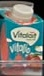
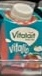
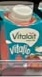
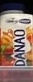
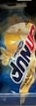
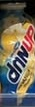
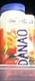
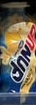
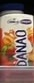
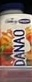
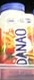
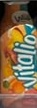
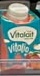
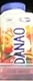
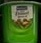
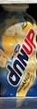
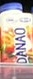
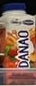
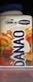
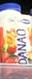
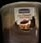
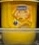
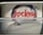
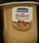
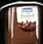
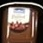
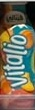
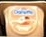
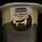
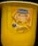
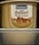
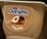
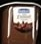
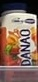
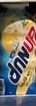
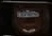
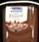
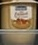
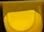
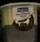
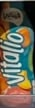
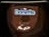
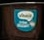
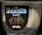
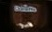
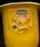
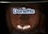
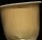
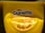
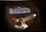
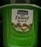
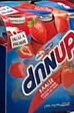
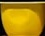
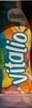
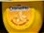
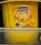
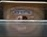
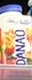
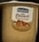
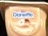
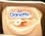
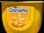
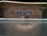
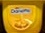
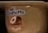
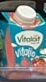
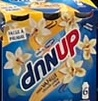
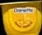
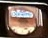
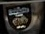
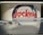
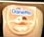
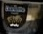
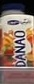
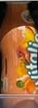
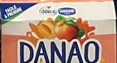
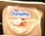
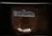
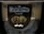
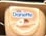
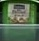
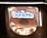
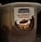
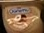
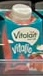
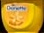
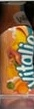
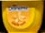
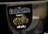
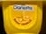
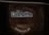
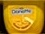
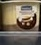
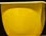
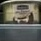
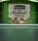
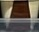
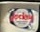
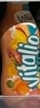
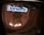
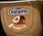
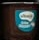
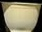
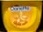
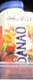
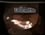
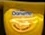
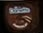
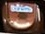
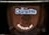
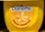
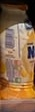
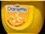
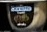
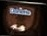
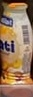
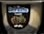
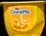
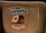
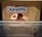
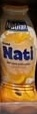
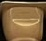
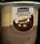
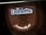
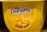
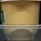
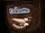
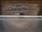
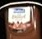
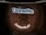
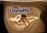
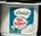
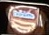
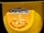
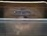
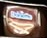
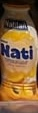
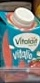
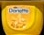
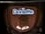
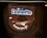
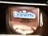
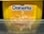
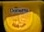
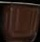
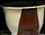
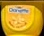
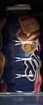
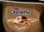
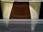
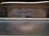
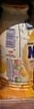
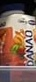
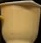
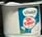
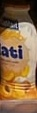
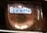
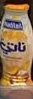
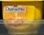
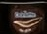
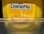
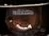
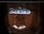
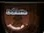
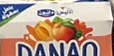
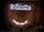
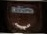
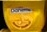
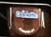
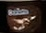
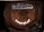
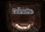
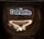
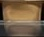
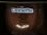
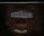
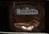
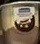
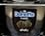
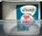
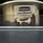
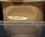
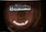
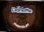
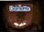
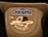
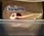
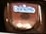
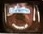
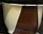
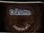
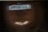
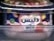
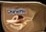
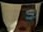
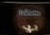
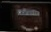
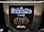
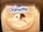
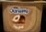
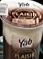
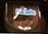
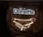
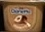
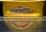
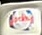
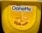
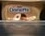
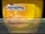
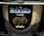
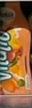
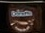
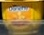
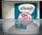
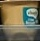
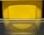
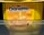
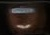
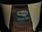
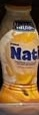
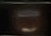
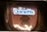
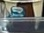
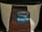
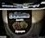
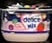
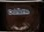
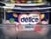
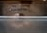
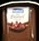
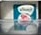
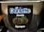
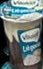
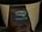
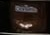
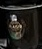
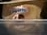
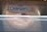
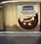
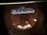
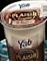
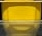
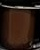
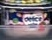
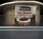
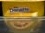
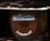
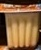
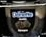
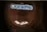
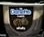
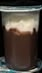
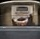
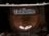
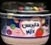
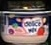
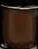
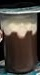
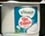
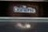
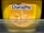
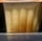
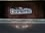
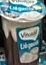
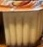
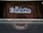
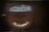
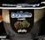
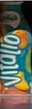
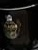
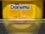
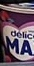
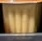
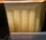
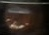
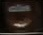
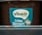
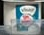
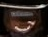
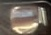
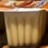
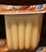
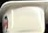
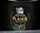
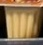
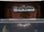
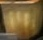
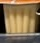
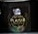
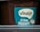
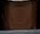
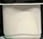
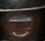
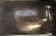
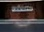
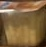
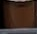
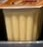
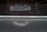
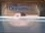
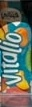
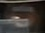
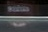
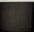
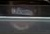
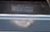
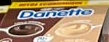
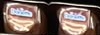
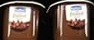
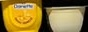
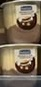
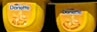
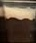
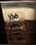
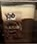
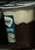
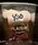

In [16]:
import glob, os, base64
from IPython.display import HTML, display

def display_crop_grid(folder='/content/crops', max_images=500, offset=0):
    # Récupère toutes les images et trie par nom
    all_images = sorted(glob.glob(f"{folder}/*.jpg"))
    total = len(all_images)

    # Sélectionne la tranche (ex: de 500 à 1000)
    images = all_images[offset : offset + max_images]

    if not images:
        print(f"Aucune image trouvée à l'index {offset}.")
        return

    print(f"Affichage des images {offset} à {min(offset + max_images, total)} sur {total} au total.")

    html_out = '<div style="display: flex; flex-wrap: wrap; height: 600px; overflow-y: scroll; border: 2px solid #4CAF50; padding: 10px; background-color: #f9f9f9;">'

    for img_path in images:
        name = os.path.basename(img_path)
        try:
            num = name.split('_')[1].split('.')[0]
        except IndexError:
            num = name

        with open(img_path, "rb") as f:
            data = base64.b64encode(f.read()).decode("utf-8")

        html_out += f'''
            <div style="margin: 10px; text-align: center; background: white; border: 1px solid #ddd; border-radius: 5px; padding: 5px;">
                <img src="data:image/jpeg;base64,{data}" style="width: 120px; height: 120px; object-fit: contain;"><br>
                <b style="color: #333;">#{num}</b>
            </div>'''

    html_out += '</div>'
    display(HTML(html_out))

# Modifiez 'offset' pour voir les suivantes : 0, 500, 1000, 1500, etc.
display_crop_grid(max_images=500, offset=0)

In [22]:
import shutil, os

# Vérification et compression de la galerie Délice
if os.path.exists('/content/gallery_delice'):
    shutil.make_archive('/content/gallery_delice', 'zip', '/content/gallery_delice')
    print("✅ Archive Délice créée.")
else:
    print("❌ Erreur : Le dossier 'gallery_delice' n'existe pas. Exécutez la cellule de tri (2. Gallery Sorting) d'abord.")

# Vérification et compression de la galerie Concurrents
if os.path.exists('/content/gallery_competitors'):
    shutil.make_archive('/content/gallery_competitors', 'zip', '/content/gallery_competitors')
    print("✅ Archive Concurrents créée.")
else:
    print("❌ Erreur : Le dossier 'gallery_competitors' n'existe pas. Exécutez la cellule de tri (2. Gallery Sorting) d'abord.")

✅ Archive Délice créée.
✅ Archive Concurrents créée.


### 2. Gallery Sorting
Use the viewer below to identify crop numbers, then run the sort function.

In [20]:
# Listes mises à jour avec vos sélections
delice_indices = [479, 480, 481, 483, 485, 486, 488, 491, 493, 494, 497, 502, 503, 507, 508, 509, 510, 511, 512, 513, 672, 756, 758, 761, 777, 802, 822, 872, 933, 997, 1008, 1017, 1036, 1063, 1072, 1253]
competitor_indices = [489, 498, 499, 501, 516, 518, 521, 522, 526, 555, 599, 647, 651, 650, 676, 685, 753, 750, 751, 755, 771, 1013, 1025, 1027, 1029, 1062, 1080, 1265, 1298]

def move_to_gallery(indices, target_folder):
    import os, shutil
    if os.path.exists(target_folder): shutil.rmtree(target_folder)
    os.makedirs(target_folder)
    for idx in indices:
        src = f"/content/crops/crop_{idx:04d}.jpg"
        if os.path.exists(src):
            shutil.copy(src, target_folder)
        else:
            print(f"⚠️ Crop #{idx:04d} introuvable.")

move_to_gallery(delice_indices, '/content/gallery_delice')
move_to_gallery(competitor_indices, '/content/gallery_competitors')
print(f"✅ Galeries préparées : {len(delice_indices)} Délice, {len(competitor_indices)} Concurrents.")

✅ Galeries préparées : 36 Délice, 29 Concurrents.


In [5]:
!unzip -q /content/gallery_delice.zip -d /content/gallery_delice
!unzip -q /content/gallery_competitors.zip -d /content/gallery_competitors

### 3. Gallery Embedding (CLIP)
This snippet computes embeddings for your reference images. You only need to rerun this if you change your gallery.

In [6]:
import glob
from PIL import Image
from sentence_transformers import SentenceTransformer, util
import torch
import torch.nn.functional as F

embedder = SentenceTransformer('sentence-transformers/clip-ViT-L-14')

def get_emb(folder):
    paths = glob.glob(f"{folder}/*.jpg")
    embs = []
    for p in paths:
        img = Image.open(p).convert("RGB").resize((384, 384))
        with torch.no_grad():
            e = embedder.encode(img, convert_to_tensor=True)
            embs.append(F.normalize(e, p=2, dim=-1))
    return torch.stack(embs) if embs else None

delice_gallery_embs = get_emb('/content/gallery_delice')
comp_gallery_embs = get_emb('/content/gallery_competitors')
print("✅ Embeddings calculated.")

modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/118 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.54k [00:00<?, ?B/s]

0_CLIPModel/model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✅ Embeddings calculated.


### 4. Target Shelf Detection
Run YOLO on the specific image you want to analyze right now.

In [8]:
import torchvision
TARGET_IMAGE = '/content/shelf_photo.jpg'
raw_img = cv2.imread(TARGET_IMAGE)
if raw_img is None:
    print(f"❌ Erreur: Impossible de charger l'image {TARGET_IMAGE}")
else:
    results = model(raw_img, size=1280)
    detections = results.xyxy[0].cpu().numpy()

    # NMS
    proposals = detections[:, :4]
    scores = detections[:, 4]
    keep_idx = torchvision.ops.nms(torch.tensor(proposals), torch.tensor(scores), 0.15)
    print(f"✅ Trouvé {len(keep_idx)} objets candidats.")

✅ Trouvé 718 objets candidats.


### 5. Final Similarity Check & Display
Classify each detection and output final counts.

In [11]:
import matplotlib.pyplot as plt
count_delice = 0
count_comp = 0
count_other = 0
vis_final = raw_img.copy()

# Paramètres ajustables
THRESHOLD_SIM = 0.60  # Seuil de similarité abaissé pour capter plus de produits
MARGIN = 0.02         # Marge de différence entre Delice et Concurrent

for i in keep_idx:
    box = proposals[i].astype(int)
    crop = raw_img[box[1]:box[3], box[0]:box[2]]
    if crop.size < 400: continue # Un peu plus permissif sur la taille

    crop_pil = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)).resize((384, 384))
    with torch.no_grad():
        emb = F.normalize(embedder.encode(crop_pil, convert_to_tensor=True), p=2, dim=-1)

    s_delice = torch.max(util.cos_sim(emb, delice_gallery_embs)).item() if delice_gallery_embs is not None else 0
    s_comp = torch.max(util.cos_sim(emb, comp_gallery_embs)).item() if comp_gallery_embs is not None else 0

    # Nouvelle logique de classification plus souple
    if s_delice > THRESHOLD_SIM and s_delice > (s_comp + MARGIN):
        label, color, count_delice = "Delice", (0, 255, 0), count_delice + 1
    elif s_comp > THRESHOLD_SIM and s_comp > (s_delice + MARGIN):
        label, color, count_comp = "Comp", (0, 0, 255), count_comp + 1
    else:
        label, color, count_other = "Other", (255, 255, 0), count_other + 1

    cv2.rectangle(vis_final, (box[0], box[1]), (box[2], box[3]), color, 3)
    # Optionnel: afficher le texte du label
    # cv2.putText(vis_final, label, (box[0], box[1]-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

print(f"--- NOUVEAUX RESULTATS (Seuil: {THRESHOLD_SIM}) ---")
print(f"Delice: {count_delice}")
print(f"Concurrents: {count_comp}")
print(f"Autres: {count_other}")

plt.figure(figsize=(20, 15))
plt.imshow(cv2.cvtColor(vis_final, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

--- NOUVEAUX RESULTATS (Seuil: 0.6) ---
Delice: 145
Concurrents: 443
Autres: 130


In [12]:
import cv2
# Sauvegarde de l'image finale pour téléchargement
output_path = '/content/resultat_final.jpg'
cv2.imwrite(output_path, vis_final)
print(f"✅ Image finale enregistrée sous : {output_path}")
print("Vous pouvez la télécharger depuis le menu de gauche (icône dossier).")

✅ Image finale enregistrée sous : /content/resultat_final.jpg
Vous pouvez la télécharger depuis le menu de gauche (icône dossier).
